O serviço de vendas de carros usados Rusty Bargain está desenvolvendo um aplicativo para atrair novos clientes. Nesse aplicativo, você pode descobrir rapidamente o valor de mercado do seu carro. Você tem acesso a dados históricos: especificações técnicas, versões de acabamento e preços. Você precisa construir o modelo para determinar o valor. 

Rusty Bargain está interessado em:

- a qualidade da predição;
- a velocidade da predição;
- o tempo necessário para o treinamento

## Preparação de Dados

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/datasets/car_data.csv')

In [4]:
import numpy as np

df = pd.read_csv('/datasets/car_data.csv')

print(df.head())
print(df.info())
print(df.describe())
print(df.isna().sum())
print(df.duplicated().sum())



        DateCrawled  Price VehicleType  RegistrationYear Gearbox  Power  \
0  24/03/2016 11:52    480         NaN              1993  manual      0   
1  24/03/2016 10:58  18300       coupe              2011  manual    190   
2  14/03/2016 12:52   9800         suv              2004    auto    163   
3  17/03/2016 16:54   1500       small              2001  manual     75   
4  31/03/2016 17:25   3600       small              2008  manual     69   

   Model  Mileage  RegistrationMonth  FuelType       Brand NotRepaired  \
0   golf   150000                  0    petrol  volkswagen         NaN   
1    NaN   125000                  5  gasoline        audi         yes   
2  grand   125000                  8  gasoline        jeep         NaN   
3   golf   150000                  6    petrol  volkswagen          no   
4  fabia    90000                  7  gasoline       skoda          no   

        DateCreated  NumberOfPictures  PostalCode          LastSeen  
0  24/03/2016 00:00               

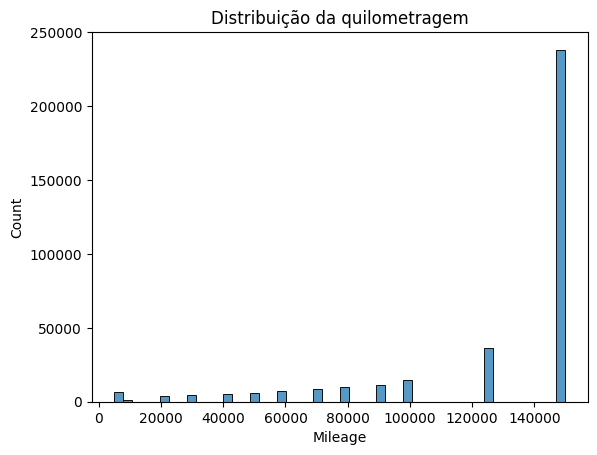

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Mileage'], bins=50)
plt.title('Distribuição da quilometragem')
plt.show()

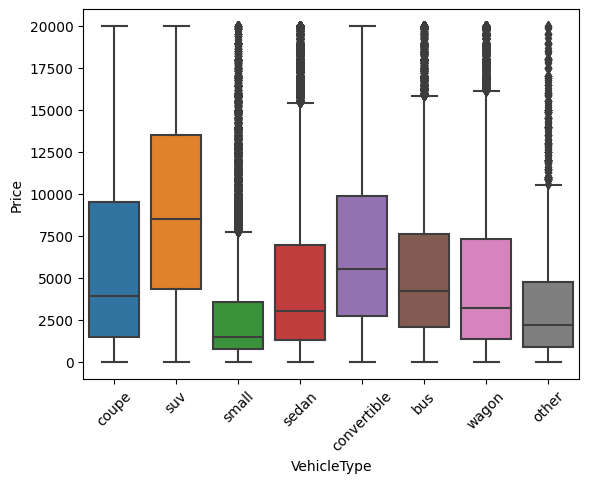

In [6]:
sns.boxplot(x='VehicleType', y='Price', data=df)
plt.xticks(rotation=45)
plt.show()

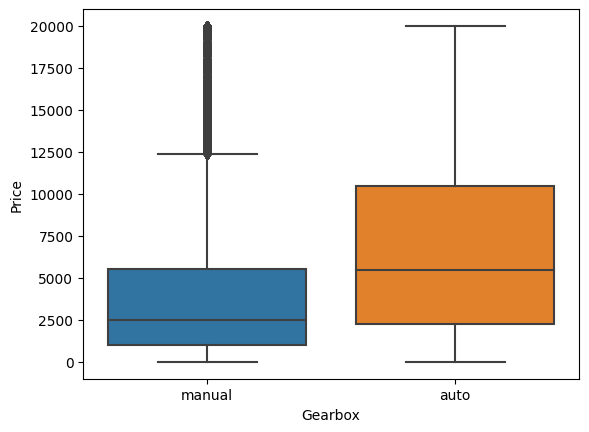

In [7]:
sns.boxplot(x='Gearbox', y='Price', data=df)
plt.show()

In [23]:
#remover valores inválidos

df = df[df['Price'] > 100]

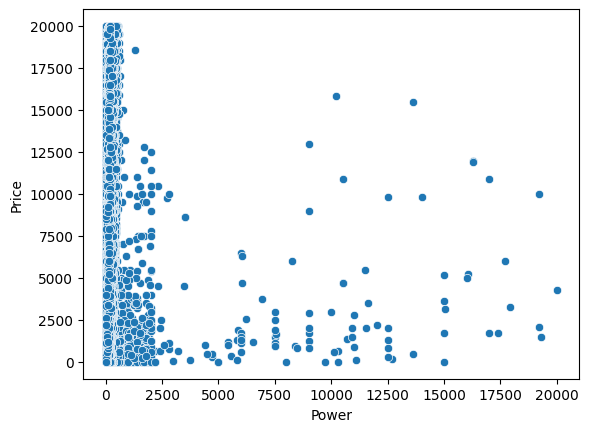

In [8]:
sns.scatterplot(x='Power', y='Price', data=df)
plt.show()

Nesta etapa, analisei a distribuição das variáveis e suas relações com o preço dos veículos.

A variável Price apresenta uma distribuição assimétrica à direita, indicando que a maioria dos carros possui preços mais baixos, com poucos valores elevados (possíveis outliers).

A quilometragem (Mileage) mostra forte concentração em valores altos, especialmente próximos de 150.000 km, sugerindo que muitos veículos já possuem uso elevado.

Ao analisar variáveis categóricas, observei que:

Veículos com câmbio automático tendem a ter preços mais altos do que os manuais.
Há variação de preço entre diferentes categorias, indicando influência dessas variáveis no valor final.

Na relação entre potência (Power) e preço, não há um padrão linear claro, mas é possível observar que veículos com maior potência tendem a apresentar preços mais altos, apesar da presença de muitos valores dispersos e outliers.

De forma geral, os dados apresentam distribuições não uniformes e valores extremos, o que será considerado nas próximas etapas de pré-processamento.

In [24]:
# remover anos inválidos

df = df[(df['RegistrationYear'] >= 1900) & (df['RegistrationYear'] <= 2016)]

In [25]:
# remover carros inválidos

df = df[(df['Power'] > 0) & (df['Power'] <= 1000)]

In [26]:
# remover coluna desncessária

df = df.drop(columns=['NumberOfPictures'])

In [27]:
# remover features com tempo pois nao será usado

df = df.drop(columns=['DateCrawled', 'DateCreated', 'LastSeen'])

In [28]:
# remover  valores ausentes

cat_cols = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'NotRepaired']

for col in cat_cols:
    df[col] = df[col].fillna('unknown')

Valores ausentes em variáveis categóricas foram tratados como uma categoria separada ("unknown"), pois a ausência de informação pode carregar significado próprio.

In [29]:
# remover pois nao tem valor

df['RegistrationMonth'] = df['RegistrationMonth'].replace(0, np.nan)
df['RegistrationMonth'] = df['RegistrationMonth'].fillna(df['RegistrationMonth'].median())

In [30]:
print(df.isna().sum())

Price                0
VehicleType          0
RegistrationYear     0
Gearbox              0
Power                0
Model                0
Mileage              0
RegistrationMonth    0
FuelType             0
Brand                0
NotRepaired          0
PostalCode           0
dtype: int64


In [31]:
# separação de dados

X = df.drop('Price', axis=1)
y = df['Price']

In [32]:
#dividir dados

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=12345
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=12345
)

O conjunto de dados foi analisado quanto a valores ausentes, inconsistências e variáveis irrelevantes. Foram identificados valores anômalos nas colunas Price, RegistrationYear e Power, como preços iguais a zero, anos irreais e potências extremamente altas. Esses valores foram removidos para evitar distorções no treinamento do modelo.

A coluna NumberOfPictures foi removida por não apresentar variabilidade. As colunas de data (DateCrawled, DateCreated, LastSeen) também foram excluídas, pois não foram utilizadas na modelagem.

Valores ausentes em variáveis categóricas foram preenchidos com a categoria "unknown", preservando a informação de ausência. A variável RegistrationMonth, que apresentava valores inválidos, foi ajustada substituindo zeros pela mediana.

Por fim, os dados foram divididos em conjuntos de treino, validação e teste para avaliação dos modelos.

## Treinamento do modelo

In [37]:
# REQM

from sklearn.metrics import mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [34]:
import time

In [35]:
from sklearn.linear_model import LinearRegression


X_train_ohe = pd.get_dummies(X_train, drop_first=True)
X_valid_ohe = pd.get_dummies(X_valid, drop_first=True)

X_train_ohe, X_valid_ohe = X_train_ohe.align(X_valid_ohe, join='left', axis=1, fill_value=0)

start = time.time()

model_lr = LinearRegression()
model_lr.fit(X_train_ohe, y_train)

train_time_lr = time.time() - start

start = time.time()

pred_lr = model_lr.predict(X_valid_ohe)

pred_time_lr = time.time() - start

rmse_lr = rmse(y_valid, pred_lr)

print("RMSE:", rmse_lr)
print("Train time:", train_time_lr)
print("Predict time:", pred_time_lr)

RMSE: 2611.6385648206997
Train time: 6.4090118408203125
Predict time: 0.09624290466308594


In [36]:
from sklearn.tree import DecisionTreeRegressor

start = time.time()

model_dt = DecisionTreeRegressor(max_depth=10, random_state=12345)
model_dt.fit(X_train_ohe, y_train)

train_time_dt = time.time() - start

start = time.time()

pred_dt = model_dt.predict(X_valid_ohe)

pred_time_dt = time.time() - start

rmse_dt = rmse(y_valid, pred_dt)

print(rmse_dt)

1983.2883012487569


In [39]:
from sklearn.ensemble import RandomForestRegressor

start = time.time()

model_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=12345,
    n_jobs=-1
)



model_rf.fit(X_train_ohe, y_train)

train_time_rf = time.time() - start

start = time.time()

pred_rf = model_rf.predict(X_valid_ohe)

pred_time_rf = time.time() - start

rmse_rf = rmse(y_valid, pred_rf)

print(rmse_rf)

1884.2181389434907


In [41]:
from lightgbm import LGBMRegressor

start = time.time()

model_lgb = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=12345
)

model_lgb.fit(X_train_ohe, y_train)

train_time_lgb = time.time() - start

start = time.time()

pred_lgb = model_lgb.predict(X_valid_ohe)

pred_time_lgb = time.time() - start

rmse_lgb = rmse(y_valid, pred_lgb)

print(rmse_lgb)

1665.3048396920988


In [42]:
from catboost import CatBoostRegressor

cat_features = X_train.select_dtypes(include='object').columns.tolist()

start = time.time()

model_cb = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_seed=12345,
    verbose=0
)

model_cb.fit(X_train, y_train, cat_features=cat_features)

train_time_cb = time.time() - start

start = time.time()

pred_cb = model_cb.predict(X_valid)

pred_time_cb = time.time() - start

rmse_cb = rmse(y_valid, pred_cb)

print(rmse_cb)

1677.558922202527


In [43]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'LightGBM', 'CatBoost'],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf, rmse_lgb, rmse_cb],
    'Train Time': [train_time_lr, train_time_dt, train_time_rf, train_time_lgb, train_time_cb],
    'Predict Time': [pred_time_lr, pred_time_dt, pred_time_rf, pred_time_lgb, pred_time_cb]
})

print(results.sort_values(by='RMSE'))

               Model         RMSE  Train Time  Predict Time
3           LightGBM  1665.304840    2.495577      0.304960
4           CatBoost  1677.558922   28.568398      0.092218
2      Random Forest  1884.218139   40.353603      0.185832
1      Decision Tree  1983.288301    2.522857      0.073391
0  Linear Regression  2611.638565    6.409012      0.096243


In [47]:

X_test_ohe = pd.get_dummies(X_test, drop_first=True)

# alinhar com treino
X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join='left', axis=1, fill_value=0)

pred_test = model_lgb.predict(X_test_ohe)
rmse_test = rmse(y_test, pred_test)

print("Test RMSE:", rmse_test)

Test RMSE: 1653.716649516111


## Análise do modelo


Foram avaliados diversos modelos para prever o preço de veículos, incluindo regressão linear, árvore de decisão, floresta aleatória, LightGBM e CatBoost. A qualidade foi medida utilizando a métrica REQM, além da análise do tempo de treinamento e predição.

A regressão linear apresentou o pior desempenho, sendo utilizada como baseline. Isso indica que o problema exige modelos mais complexos para capturar relações não lineares nos dados.

Modelos baseados em árvores apresentaram melhor desempenho, com destaque para a floresta aleatória. No entanto, esse modelo apresentou alto custo computacional.

Os melhores resultados foram obtidos com modelos de gradient boosting. O LightGBM apresentou o menor REQM no conjunto de validação e também no conjunto de teste (REQM ≈ 1653), além de baixo tempo de treinamento, demonstrando excelente capacidade de generalização.

O CatBoost apresentou desempenho semelhante, porém com maior tempo de treinamento.

Portanto, o LightGBM foi escolhido como o modelo final, por oferecer o melhor equilíbrio entre qualidade de predição e eficiência computacional.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- Os resultados dos modelos experimentados foram analisados
- O melhor modelo teve error inferior a `2500` RMSE no conjunto de teste
- O tempo de treinamento foi considerado na conclusão final
</div>